# Assignment 1: Image Representation and Visual Exploration

**Individual · 75 points**

This assignment asks one connected question: **how does representation change what we see, compute, and communicate?** Complete the important array operations in `src/student_code.py`; use the provided helpers only for paths, plotting layout, asset integrity, and portable video I/O.

## 0. Student Information

- First name: Bryan  
- Last name: Palomo 
- ABC123: tkq516
- External resources and generative-AI assistance: **None**

This is an individual assignment. Do not install unapproved packages or use external libraries or pretrained pipelines to bypass a required implementation.

Generative AI tools may be used for conceptual clarification, debugging assistance, code suggestions, and help interpreting documentation. Students must disclose meaningful use in every assignment. You remain responsible for understanding, testing, and explaining all submitted work. AI may not replace your own experimental analysis, failure analysis, reflection, or interpretation of observed results. You may be asked to explain selected work; inability to do so may reduce credit or lead to an academic-integrity review.


## 1. Assignment Overview and Learning Objectives

By completing A1, you should be able to load, inspect, display, save, and manipulate image arrays; reason about shape, channel order, dtype, and range; compare grayscale/RGB/BGR/HSV representations; perform controlled experiments; and read, sample, transform, write, and verify video.

**Point map:** core implementation 30; required experiments 19; results/analysis/failure reasoning 15; reproducibility/submission 7; extension 4.

| Tables & Metadata | Figures | Other Outputs |
|---|---|---|
| `image_metadata.csv` | `image_overview.png` | `a1_transformed.mp4` |
| `timing.csv` | `numpy_manipulations.png` | one declared extension artifact |
| `experiment_metrics.csv` | `dtype_range_experiment.png` | |
| `video_metadata.json` | `color_representations.png` | |
| | `hsv_stability.png` | |
| | `video_contact_sheet.png` | |
| | `failure_image.png`, `failure_video.png` | |


## 2. Environment Verification

Run this cell first. It discovers the repository from the installed course package rather than the terminal working directory. A clean checksum list is required. If it fails, run the A1 preflight command from the README.


In [1]:
from pathlib import Path
import json, sys, time
import cv2
import imageio.v3 as iio
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import cs5243
from cs5243.data import find_course_root
COURSE_ROOT = find_course_root(Path(cs5243.__file__))
A1 = COURSE_ROOT / "A1"
sys.path.insert(0, str(A1 / "src"))
import a1_tools
import student_code as sc
PATHS = a1_tools.ensure_output_directories()
assert a1_tools.verify_asset_hashes() == []
print({"assignment": "A1-2026.1", "environment": "2026.1"})


{'assignment': 'A1-2026.1', 'environment': '2026.1'}


## 3. Dataset and Problem Setup

The course-staff-generated CC0 dataset contains strong channel-order cues, aligned illumination variants, uint16 intensities, different aspect ratios, and a four-second MP4. Do not move or edit assets.

### Task 1 — inspect and communicate image arrays (6 points)

Implement `image_summary`. Load each image without silently discarding its native dtype. Save `outputs/tables/image_metadata.csv` with filename, shape, height, width, channels, dtype, minimum, maximum, mean, and bytes. Inspect at least three named pixels, including a channel-order swatch. Save a captioned overview as `outputs/figures/image_overview.png`. Explain immediately below what shape order means and how the array represents a pixel.

Implement reusable graded functions in `src/student_code.py`; use the notebook to call those functions, conduct experiments, save required artifacts, and explain the results.


red pixel at (130, 140) RGB = [235  35  35]
green pixel at (130, 340) RGB = [ 35 210  65]
blue pixel at (130, 650) RGB = [ 40  90 240]


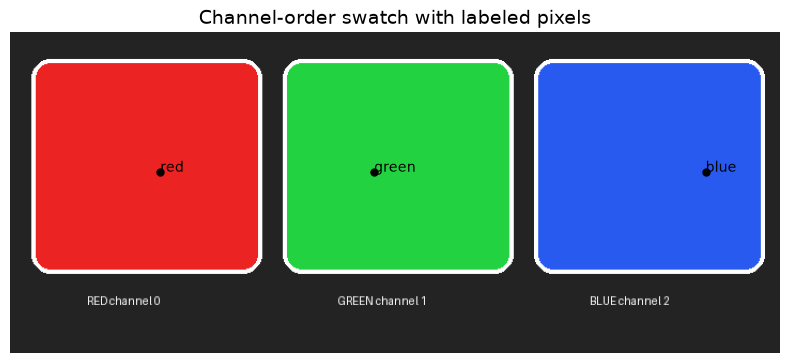

In [ ]:
# STUDENT WORK — Task 1
image_paths: list[Path] = a1_tools.discover_images()
# Load, summarize, save image_metadata.csv, and create image_overview.png.
rows = []
for path in image_paths:
    img = cv2.imread(path, cv2.IMREAD_UNCHANGED)
    metadata = sc.image_summary(img)
    metadata['filename'] = Path(path).name
    metadata['minimum'] = metadata['range'][0]
    metadata['maximum'] = metadata['range'][1]
    metadata.pop('range')
    rows.append(metadata)

df = pd.DataFrame(rows)
df.to_csv('outputs/tables/image_metadata.csv', index=False)

# Image overview

ch_ord = cv2.imread('data/images/channel_order.png', cv2.IMREAD_UNCHANGED)
ch_ord = ch_ord[:, :, ::-1]
fig, ax = plt.subplots(figsize=(8,4))
ax.imshow(ch_ord)
ax.axis('off')

named_pixels = {
    "red": (130, 140),
    "green": (130, 340),
    "blue": (130, 650),
}

for color, (row,col) in named_pixels.items():
    value = ch_ord[row, col]
    print(f"{color} pixel at ({row}, {col}) RGB = {value}")

for color, (row,col) in named_pixels.items():
    ax.plot(col, row, 'k.', markersize=8, markeredgewidth=2)
    ax.annotate(color, (col, row), color="black", fontsize=10)

ax.set_title("Channel-order swatch with labeled pixels", fontsize=14)
fig.tight_layout()
fig.savefig('outputs/figures/image_overview.png', dpi=150, bbox_inches='tight')
plt.show()

**Task 1 analysis (3–5 sentences):** YOUR RESPONSE. Cite array values and distinguish `(height, width, channels)` from `(width, height)`.


## 4. Core Implementation

### Task 2 — NumPy spatial/channel operations (11 points)

Implement crop, horizontal flip, channel extraction/reordering, rectangular replacement, and contact-sheet construction using NumPy. Crops and replacements must be positive, in bounds, and non-mutating. A contact-sheet call must contain either all grayscale or all RGB `uint8` images; top-left-align them with an 8-pixel outer border and gutter. Make one coherent comparison using `channel_order.png`, `portrait_scene.png`, and `wide_scene.jpg`. Do not use OpenCV functions that directly perform these graded operations. Save `outputs/figures/numpy_manipulations.png` with a descriptive caption.


In [ ]:
# STUDENT WORK — Task 2
# Demonstrate each implementation and save numpy_manipulations.png.
raise NotImplementedError("Complete Task 2")


**Task 2 analysis (2–4 sentences):** YOUR RESPONSE. Identify what was reordered versus what changed spatially.


### Task 3 — loop and vectorized arithmetic (6 points)

Implement `brighten_loop` and `brighten_vectorized` using `np.rint` nearest-even rounding before clipping to `[0, 255]` and conversion to `uint8`. Time each at least three times on the same image using `time.perf_counter`; report median milliseconds, repeat count, and output equality in `outputs/tables/timing.csv`. Timing supports a representation argument; it is not a benchmarking contest.


In [ ]:
# STUDENT WORK — Task 3
raise NotImplementedError("Complete Task 3 and write timing.csv")


**Task 3 analysis (2–3 sentences):** YOUR RESPONSE. Report the measured ratio and explain why the comparison is controlled.


### Task 4 — datatype/range safety (7 points)

Implement `to_float01` and `to_uint8_safe`. Diagnose and repair this deliberately incorrect conversion:

```python
wrong = (float_image * 255).astype(np.uint8)  # no range check; truncates and wraps
```

Compare uint8 addition with float addition, include the uint16 ramp, and save `outputs/figures/dtype_range_experiment.png`. Record at least three quantitative comparisons in `outputs/tables/experiment_metrics.csv`.

Analyze uint8 overflow and float-to-uint8 conversion as two distinct failure mechanisms.


In [ ]:
# STUDENT WORK — Task 4
raise NotImplementedError("Complete Task 4 and save its figure/table")


**Task 4 analysis (3–5 sentences):** YOUR RESPONSE. Use observed values to explain overflow, clipping, normalization, and the corrected conversion.


## 5. Required Experiments

### Experiment 1 — channel order and grayscale interpretation (8 points)

Implement both grayscale functions. Compare: correct RGB display; BGR interpreted as RGB; channel mean; luminance-weighted grayscale; and OpenCV grayscale with the correct input convention. Hold the source image and display limits fixed. Save `outputs/figures/color_representations.png`.


In [ ]:
# STUDENT WORK — Experiment 1
raise NotImplementedError("Complete Experiment 1")


**Experiment 1 analysis (4–6 sentences):** YOUR RESPONSE. State which evidence separates a channel-order error from a grayscale-weighting choice.


### Experiment 2 — HSV rule stability (7 points)

Implement the inclusive OpenCV-HSV rule, including wrapped hue intervals. Use one rule and the exactly aligned normal, dim, and warm images. Report selected-pixel fraction (and one other useful metric) for every condition. Append the results to the cumulative `experiment_metrics.csv`. Save `outputs/figures/hsv_stability.png`. This is a controlled color-rule investigation, not a segmentation assignment.


In [ ]:
# STUDENT WORK — Experiment 2
raise NotImplementedError("Complete Experiment 2")


**Experiment 2 analysis (3–5 sentences):** YOUR RESPONSE. Explain the strongest and weakest condition using HSV evidence, without claiming general segmentation performance.


### Experiment 3 — video as a sampled visual array (4 points)

Probe `moving_shapes.mp4` and record the required input, output, and read-back structure in `outputs/tables/video_metadata.json`. Extract frames near 0.0, 1.0, 2.0, and 3.0 seconds and save `outputs/figures/video_contact_sheet.png`. Implement `transform_frame` to flip an RGB frame horizontally and multiply its red channel by `0.65`, returning `HxWx3 uint8`. Apply it to all frames, write `outputs/videos/a1_transformed.mp4` using `a1_tools.write_mp4`, then verify read-back with `a1_tools.verify_video_round_trip`. The bundled imageio-ffmpeg path is required; OpenCV `VideoWriter` is not graded or required.


In [ ]:
# STUDENT WORK — Experiment 3
raise NotImplementedError("Complete Experiment 3")


**Experiment 3 analysis (3–4 sentences):** YOUR RESPONSE. Cite input/output metadata and state what read-back proves—and what it does not prove.


## 6. Results and Analysis

The immediate analysis prompts following Tasks 1–4 and Experiments 1–3 are worth **5 points collectively**. Use this synthesis to connect your findings rather than restating earlier observations. The final synthesis is worth **3 points**: in at most 180 words, address only (1) the most important representation lesson, (2) the strongest experimental finding, and (3) one important limitation observed in the completed experiments. Tie each claim to a saved artifact or measured value.


**Final synthesis:** YOUR RESPONSE.


## 7. Failure Analysis

### Task 5 — evidence, mechanism, correction (7 points)

Document two failures: one image-representation failure and one video/encoding-related failure. One acceptable controlled video case is calculating a frame index using `time × frame_count` instead of `time × FPS`. Show the incorrect result, explain the units error, correct it, and verify the corrected frame selection. You may instead analyze another reproducible video or encoding-related failure. Save `outputs/figures/failure_image.png` and `outputs/figures/failure_video.png`.


In [ ]:
# STUDENT WORK — Failure evidence
raise NotImplementedError("Create both failure figures")


**Image failure analysis:** YOUR RESPONSE.

**Video failure analysis:** YOUR RESPONSE.


## 8. Extension

### Task 6 — Extension (4 points)

Choose one: color-based highlighting; short video summary; another color representation; false-color visualization; compression/resizing comparison; or visual storytelling with existing transformations. Require only **one clear question, one controlled comparison, one principal saved output, and one concise evidence-based conclusion**. Use no additional packages or major algorithms. Retain exactly one file under `outputs/extension/` (PNG, JPG, MP4, CSV, JSON, or TXT); delete any temporary extension files before submission.


In [ ]:
# STUDENT WORK — Extension
raise NotImplementedError("Complete one extension")


**Question and conclusion (80–130 words total):** YOUR RESPONSE.


## 9. Reflection and Reproducibility

In 100–150 words: state one practice you will carry into later assignments; one result another person should be able to reproduce; and any platform-dependent behavior. Update the assistance disclosure in Section 0. Do not restate all experiment findings.


**Reflection:** YOUR RESPONSE.


## 10. Submission Validation

Restart the kernel and run all cells. Export current HTML as `A1.html`. Then run full validation and packaging using the absolute repository path if your terminal is elsewhere:

```bash
python /path/to/common-setup/scripts/validate_submission.py --assignment A1
python /path/to/common-setup/scripts/package_submission.py --assignment A1
```

Submit the generated ASCII-safe `LastName_FirstName_A1.zip`. It must contain one top-level folder with the executed notebook, current HTML, source, selected outputs, and validation report. Do not submit a PDF, datasets, caches, environments, checkpoints, or ZIPs inside the ZIP.


### Canvas submission checklist

- [ ] The ZIP contains exactly one top-level folder named `LastName_FirstName_A1`.
- [ ] Section 0 identity fields (first name, last name, ABC123) are complete.
- [ ] `A1.ipynb` was restarted, run top to bottom, and saved without errors, and `A1.html` was exported after that final run.
- [ ] `src/` contains the required source files: `a1_tools.py` and `student_code.py`.
- [ ] `outputs/` contains only the required figures, tables, the transformed video, and one extension artifact — no extra files.
- [ ] `python scripts/validate_submission.py --assignment A1` reports zero errors; review any warnings.
- [ ] No datasets, environments, caches, checkpoints, hidden files, or temporary files are included.
- [ ] External resources and meaningful generative-AI use are disclosed in Section 0.
- [ ] A PDF export is not required and is not included.


In [ ]:
# Final local inventory (does not replace command-line validation)
for category in ("figures", "tables", "videos", "extension"):
    print(category, sorted(path.name for path in PATHS[category].glob("*") if path.is_file()))
